<a href="https://colab.research.google.com/github/Gianluca-dot/Project-Deep-Learning-e-Reti-Neurali/blob/main/Copia_di_Modello_di__previsione_per_il_mercato_immobiliare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Un modello di previsione per il mercato immobiliare
RealEstateAI Solutions si propone di ottimizzare la valutazione dei prezzi immobiliari attraverso l'uso di tecniche avanzate di regolarizzazione in modelli di regressione lineare. L'obiettivo è fornire previsioni di prezzo più accurate e affidabili, riducendo il rischio di overfitting e migliorando la capacità di generalizzazione del modello.

Nel settore immobiliare, ottenere stime precise dei prezzi delle proprietà è cruciale per prendere decisioni informate. Tuttavia, i modelli di regressione lineare tradizionali possono soffrire di overfitting, compromettendo l'accuratezza delle previsioni. È necessario esplorare metodi di regolarizzazione efficaci per migliorare le performance predittive e gestire la complessità del modello.

Implementando e confrontando metodi di regolarizzazione come Lasso, Ridge e Elastic Net, RealEstateAI Solutions offrirà un sistema in grado di fornire previsioni di prezzo immobiliari più accurate e stabili. Questo permetterà agli agenti immobiliari e agli investitori di prendere decisioni basate su dati più affidabili, aumentando la loro competitività nel mercato.

Requisiti del Progetto:

Preparazione del Dataset:
Caricamento e preprocessamento dei dati sui prezzi immobiliari.
Gestione dei valori mancanti, codifica delle variabili categoriche e normalizzazione/scalatura dei dati.
Implementazione dei Modelli di Regressione:
Ridge Regression: Implementazione e addestramento del modello con regolarizzazione Ridge.
Lasso Regression: Implementazione e addestramento del modello con regolarizzazione Lasso.
Elastic Net Regression: Implementazione e addestramento del modello con regolarizzazione Elastic Net.
Valutazione delle Performance:
Utilizzo di tecniche di validazione incrociata.
Calcolo del Mean Squared Error (MSE) per ciascun modello.
Confronto della complessità dei modelli valutando il numero di coefficienti non nulli.
Analisi e confronto dei risultati dei vari metodi di regolarizzazione.
Visualizzazione dei Risultati:
Creazione di grafici per visualizzare e confrontare le performance dei modelli.
Visualizzazione della distribuzione dei residui per valutare l'adeguatezza del modello.
Il progetto deve includere il codice sorgente completo, con commenti dettagliati che spiegano i vari passaggi, le scelte fatte e i risultati ottenuti, per garantire trasparenza e replicabilità del lavoro.

Il dataset
Il dataset è disponibile qui: https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv (liberamente tratto dal seguente dataset: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

Price: il prezzo, il target da prevedere
Area: superficie dell’immobile
Bedrooms: numero di camere da letto
Bathrooms: numero di bagni
Stories: numero di piani
Mainroad: vale 1 se l’immobile affaccia su una strada principale, 0 altrimenti
guestroom: vale 1 se l’immobile ha una stanza degli ospiti, 0 altrimenti
basement: vale 1 se l’immobile ha un seminterrato, 0 altrimenti
hotwaterheating: vale 1 se l’immobile ha una caldaia, 0 altrimenti
airconditioning: vale 1 se l’immobile ha l’aria condizionata, 0 altrimenti
parking: numero di parcheggi
prefarea: vale 1 se l’immobile è in una zona prestigiosa, 0 altrimenti
Furnishingstatus: vale 0 se l’immobile non è arredato, 1 se è parzialmente arredato, 2 se è completamente arredato

# CARICAMENTO DEL DATASET E PRESA VISIONE

In [ ]:
import pandas as pd

# URL del dataset
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv"

# dataset in un DataFrame pandas
df = pd.read_csv(url)

print("Dataset caricato con successo. Prime 5 righe:")
print(df.head())

print("numero di colonne nel Dataset")
df.shape

print("\nInformazioni sul DataFrame (tipi di dati e valori non-nulli):")
df.info()

print("\nRiepilogo delle statistiche descrittive:")
print(df.describe())

Dataset caricato con successo. Prime 5 righe:
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 1  
1                 1  
2                 2  
3                 1  
4 

### Distribuzione delle Variabili Numeriche
da confrontare con la distribuzione, dopo la standardizzazione.

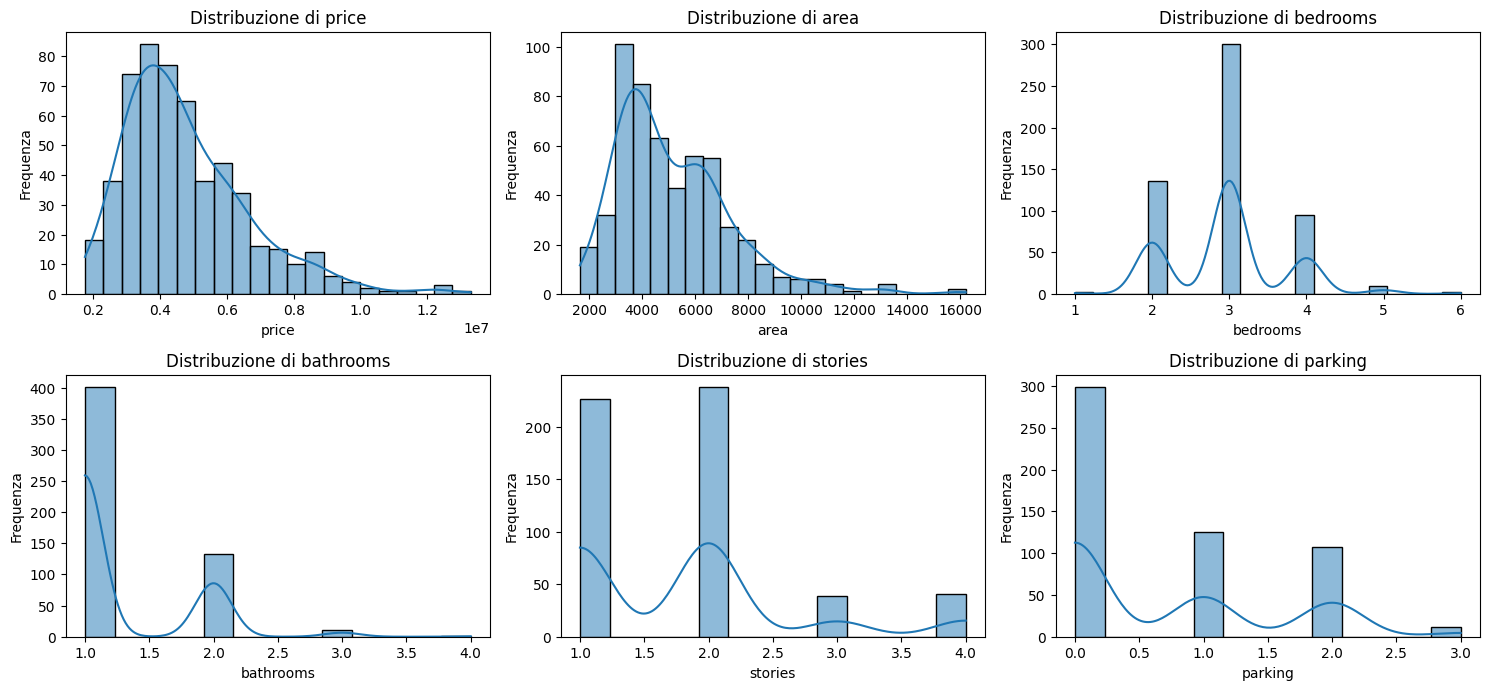

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifichiamo le colonne numeriche per l'istogramma
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuzione di {col}')
    plt.xlabel(col)
    plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

### Distribuzione delle Variabili Categoriche



In [ ]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

for col in categorical_cols:
    print(f"\nConteggio valori per la colonna '{col}':")
    display(df[col].value_counts())
    print("-" * 30)


Conteggio valori per la colonna 'mainroad':


,count
mainroad,
1,468
0,77


------------------------------

Conteggio valori per la colonna 'guestroom':


,count
guestroom,
0,448
1,97


------------------------------

Conteggio valori per la colonna 'basement':


...

------------------------------

Conteggio valori per la colonna 'prefarea':


,count
prefarea,
0,417
1,128


------------------------------

Conteggio valori per la colonna 'furnishingstatus':


,count
furnishingstatus,
2,227
0,178
1,140


------------------------------


Applichiamo il One-Hot-Encoding alla variabile furnishingstatus

In [ ]:
print("Codifica One-Hot per 'furnishingstatus'...")
df = pd.get_dummies(df, columns=['furnishingstatus'], prefix='furnishing')

print("DataFrame dopo One-Hot Encoding (prime 5 righe):")
display(df.head())

print("Nuove colonne create:")
print([col for col in df.columns if 'furnishing' in col])

Codifica One-Hot per 'furnishingstatus'...
DataFrame dopo One-Hot Encoding (prime 5 righe):


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_0,furnishing_1,furnishing_2
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,True,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,True,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,False,True
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,True,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,True,False


Nuove colonne create:
['furnishing_0', 'furnishing_1', 'furnishing_2']


Divisione del Dataset in Training Test (70%) e Test Set(30%)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dimensioni del training set (X_train, y_train): {X_train.shape}, {y_train.shape}")
print(f"Dimensioni del test set (X_test, y_test): {X_test.shape}, {y_test.shape}")

Dimensioni del training set (X_train, y_train): (381, 14), (381,)
Dimensioni del test set (X_test, y_test): (164, 14), (164,)


Standardizzazione con StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Ricostruiamo i DataFrame scalati (opzionale ma utile per visualizzazione e debugging)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("DataFrame di training scalato (prime 5 righe):")
display(X_train_scaled_df.head())

print("\nDataFrame di test scalato (prime 5 righe):")
display(X_test_scaled_df.head())

DataFrame di training scalato (prime 5 righe):


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_0,furnishing_1,furnishing_2
126,0.934301,0.055861,-0.553238,-0.907660,0.397561,-0.478573,1.334549,-0.235376,-0.682191,1.591603,1.798147,1.492921,-0.596550,-0.86470
363,-0.710246,-1.274325,-0.553238,-0.907660,0.397561,-0.478573,-0.749317,4.248529,-0.682191,-0.800511,-0.556128,-0.669828,-0.596550,1.15647
370,-0.390167,-1.274325,-0.553238,-0.907660,0.397561,-0.478573,-0.749317,-0.235376,1.465865,1.591603,-0.556128,-0.669828,-0.596550,1.15647
31,0.860719,0.055861,-0.553238,2.573733,0.397561,-0.478573,-0.749317,-0.235376,1.465865,1.591603,-0.556128,-0.669828,-0.596550,1.15647
113,2.065617,0.055861,-0.553238,-0.907660,0.397561,-0.478573,1.334549,-0.235376,-0.682191,1.591603,1.798147,-0.669828,1.676305,-0.86470



DataFrame di test scalato (prime 5 righe):


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishing_0,furnishing_1,furnishing_2
316,0.354846,1.386046,1.554599,0.252805,-2.515338,-0.478573,1.334549,-0.235376,-0.682191,0.395546,-0.556128,1.492921,-0.596550,-0.86470
77,0.630777,0.055861,1.554599,1.413269,0.397561,-0.478573,-0.749317,-0.235376,1.465865,-0.800511,1.798147,-0.669828,1.676305,-0.86470
360,-0.500539,-1.274325,-0.553238,-0.907660,0.397561,-0.478573,-0.749317,-0.235376,-0.682191,-0.800511,-0.556128,-0.669828,-0.596550,1.15647
90,-0.059050,0.055861,-0.553238,0.252805,0.397561,-0.478573,-0.749317,-0.235376,1.465865,-0.800511,-0.556128,-0.669828,-0.596550,1.15647
493,-0.537330,0.055861,-0.553238,-0.907660,0.397561,-0.478573,-0.749317,-0.235376,-0.682191,-0.800511,-0.556128,-0.669828,1.676305,-0.86470


Distribuzione delle variabili dopo la distibuzione, da confontare, con i grafici precedenti. I grafici confermano che la standardizzazione ha centrato i dati, rendendo le loro scale comparabili.

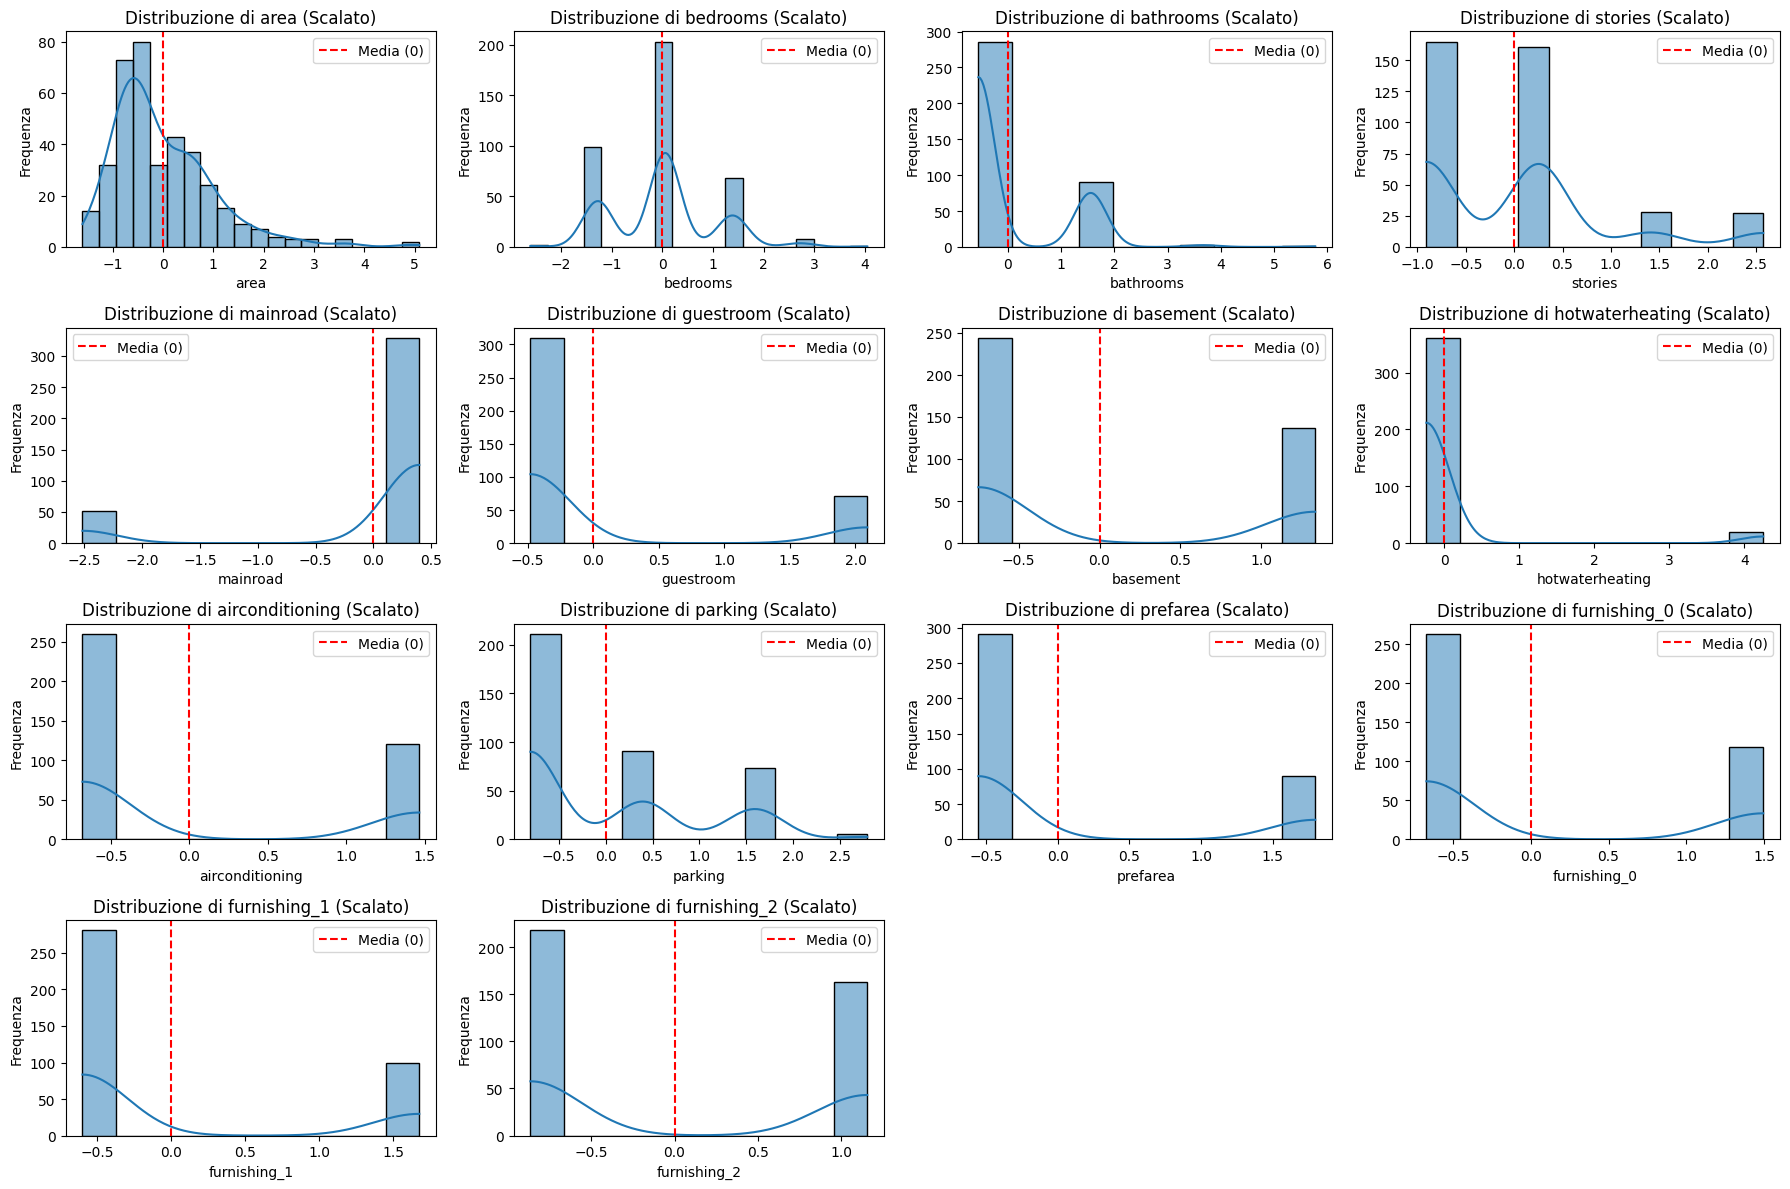

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifichiamo le colonne numeriche scalate (tutte le colonne di X_train_scaled_df)
scaled_numerical_cols = X_train_scaled_df.columns

plt.figure(figsize=(18, 12))
for i, col in enumerate(scaled_numerical_cols):
    plt.subplot(4, 4, i + 1) # Aumentiamo le dimensioni della griglia se ci sono più feature
    sns.histplot(X_train_scaled_df[col], kde=True)
    plt.title(f'Distribuzione di {col} (Scalato)')
    plt.xlabel(col)
    plt.ylabel('Frequenza')
    plt.axvline(0, color='red', linestyle='--', label='Media (0)') # Aggiungiamo una linea per la media 0
    plt.legend()
plt.tight_layout()
plt.show()

Definizione della Funzione evaluate_model

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, dataset):
  X, y = dataset
  y_pred = model.predict(X)
  print(f"MSE: {mean_squared_error(y, y_pred):.3f}")
  print(f"R2: {r2_score(y, y_pred):.3f}")


Ordinary Squares Regression

Addestreremo un modello di regressione lineare standard (OLS) e valuteremo le sue prestazioni sia sul training set che sul test set. Questo servirà come baseline per confrontare l'efficacia dei modelli regolarizzati.

In [ ]:
# Inizializzazione e addestramento del modello OLS
linear_model = LinearRegression()
linear_model.fit(X_train_scaled_df, y_train)

print("Valutazione su Training Set (OLS):")
evaluate_model(linear_model, (X_train_scaled_df, y_train))

print("\nValutazione su Test Set (OLS):")
evaluate_model(linear_model, (X_test_scaled_df, y_test))


Valutazione su Training Set (OLS):
MSE: 963835379828.360
R2: 0.693

Valutazione su Test Set (OLS):
MSE: 1523019469501.290
R2: 0.646


### Ridge Regression

Implementeremo la regressione Ridge con un valore di `alpha` fisso (es. `alpha=1.0`). Verrà addestrato il modello e valutato sul training e test set per osservare come la penalità L2 influisce sulle prestazioni.

In [ ]:
# Inizializzazione e addestramento del modello Ridge con alpha fisso
ridge_model_fixed_alpha = Ridge(alpha=1.0)
ridge_model_fixed_alpha.fit(X_train_scaled_df, y_train)

print("Valutazione su Training Set (Ridge alpha=1.0):")
evaluate_model(ridge_model_fixed_alpha, (X_train_scaled_df, y_train))

print("\nValutazione su Test Set (Ridge alpha=1.0):")
evaluate_model(ridge_model_fixed_alpha, (X_test_scaled_df, y_test))


Valutazione su Training Set (Ridge alpha=1.0):
MSE: 963840477014.073
R2: 0.693

Valutazione su Test Set (Ridge alpha=1.0):
MSE: 1522929774487.557
R2: 0.646


### Lasso Regression

Implementeremo la regressione Lasso con un valore di `alpha` fisso (es. `alpha=1.0`). Verrà addestrato il modello e valutato, prestando attenzione all'effetto della penalità L1 sulla selezione delle feature e sulle prestazioni.

In [ ]:
# Inizializzazione e addestramento del modello Lasso con alpha fisso
lasso_model_fixed_alpha = Lasso(alpha=1.0, max_iter=2000) # Aggiunto max_iter per evitare ConvergenceWarning
lasso_model_fixed_alpha.fit(X_train_scaled_df, y_train)

print("Valutazione su Training Set (Lasso alpha=1.0):")
evaluate_model(lasso_model_fixed_alpha, (X_train_scaled_df, y_train))

print("\nValutazione su Test Set (Lasso alpha=1.0):")
evaluate_model(lasso_model_fixed_alpha, (X_test_scaled_df, y_test))


Valutazione su Training Set (Lasso alpha=1.0):
MSE: 963835379835.399
R2: 0.693

Valutazione su Test Set (Lasso alpha=1.0):
MSE: 1523019737886.313
R2: 0.646


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.524e+13, tolerance: 1.197e+11
  model = cd_fast.enet_coordinate_descent(


### Elastic Net Regression

Implementeremo la regressione Elastic Net con valori fissi per `alpha` e `l1_ratio` (es. `alpha=1.0`, `l1_ratio=0.5`). Questo modello combina le penalità L1 e L2. Verrà addestrato e valutato come gli altri.

In [ ]:
# Inizializzazione e addestramento del modello Elastic Net con alpha e l1_ratio fissi
elastic_net_model_fixed_params = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2000) # Aggiunto max_iter per evitare ConvergenceWarning
elastic_net_model_fixed_params.fit(X_train_scaled_df, y_train)

print("Valutazione su Training Set (Elastic Net alpha=1.0, l1_ratio=0.5):")
evaluate_model(elastic_net_model_fixed_params, (X_train_scaled_df, y_train))

print("\nValutazione su Test Set (Elastic Net alpha=1.0, l1_ratio=0.5):")
evaluate_model(elastic_net_model_fixed_params, (X_test_scaled_df, y_test))


Valutazione su Training Set (Elastic Net alpha=1.0, l1_ratio=0.5):
MSE: 1049142863435.747
R2: 0.666

Valutazione su Test Set (Elastic Net alpha=1.0, l1_ratio=0.5):
MSE: 1642106758316.027
R2: 0.619


Risoluzione del task numero 3

Valutazione delle Performance:
Utilizzo di tecniche di validazione incrociata.
Calcolo del Mean Squared Error (MSE) per ciascun modello.
Confronto della complessità dei modelli valutando il numero di coefficienti non nulli.
Analisi e confronto dei risultati dei vari metodi di regolarizzazione.


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Modelli
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=2000),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2000)
}

results = []

for name, model in models.items():

    # Cross-validation a 5 fold
    scores = cross_val_score(
        model,
        X_train_scaled_df,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    # Trasformiamo i valori negativi in MSE positivi
    mse_cv = -scores.mean()

    # Addestramento del modello
    model.fit(X_train_scaled_df, y_train)

    # Numero di coefficienti diversi da zero
    non_zero = np.sum(model.coef_ != 0)

    results.append([
        name,
        mse_cv,
        non_zero
    ])

# Tabella finale
results_df = pd.DataFrame(
    results,
    columns=["Modello", "MSE Cross-Validation", "Coefficienti non nulli"]
)

print(results_df)

       Modello  MSE Cross-Validation  Coefficienti non nulli
0          OLS          1.103291e+12                      14
1        Ridge          1.102886e+12                      14
2        Lasso          1.103291e+12                      14
3  Elastic Net          1.158702e+12                      14


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.028e+13, tolerance: 8.339e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.208e+13, tolerance: 1.070e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.406e+13, tolerance: 1.010e

Risoluzione del task numero 4

Visualizzazione dei Risultati:
Creazione di grafici per visualizzare e confrontare le performance dei modelli.
Visualizzazione della distribuzione dei residui per valutare l'adeguatezza del modello.

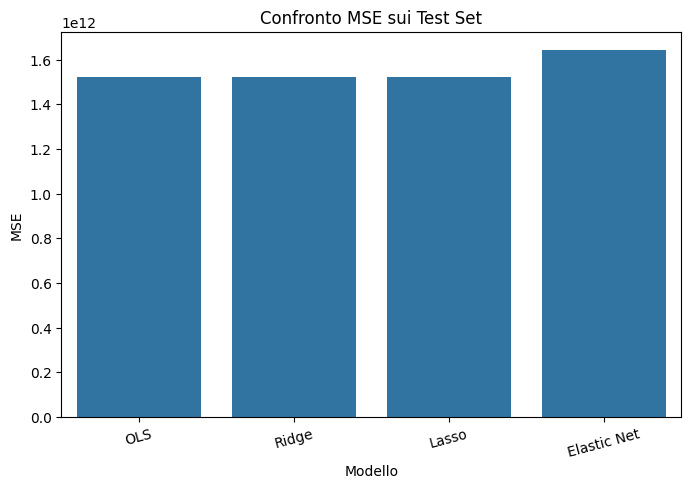

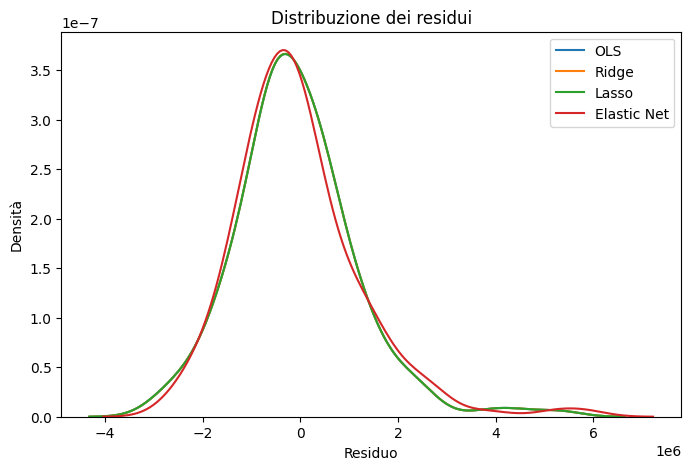

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# MSE dei modelli
mse_test = []
nomi_modelli = []

for name, model in models.items():

    y_pred = model.predict(X_test_scaled_df)
    mse = mean_squared_error(y_test, y_pred)

    nomi_modelli.append(name)
    mse_test.append(mse)

# Grafico confronto MSE
plt.figure(figsize=(8, 5))

sns.barplot(
    x=nomi_modelli,
    y=mse_test
)

plt.title("Confronto MSE sui Test Set")
plt.xlabel("Modello")
plt.ylabel("MSE")
plt.xticks(rotation=15)
plt.show()


# Distribuzione dei residui
plt.figure(figsize=(8, 5))

for name, model in models.items():

    y_pred = model.predict(X_test_scaled_df)
    residui = y_test - y_pred

    sns.kdeplot(
        residui,
        label=name
    )

plt.title("Distribuzione dei residui")
plt.xlabel("Residuo")
plt.ylabel("Densità")
plt.legend()
plt.show()

## Considerazioni finali

Il lavoro svolto ha avuto l’obiettivo di sviluppare e confrontare diversi modelli di regressione per la previsione del **prezzo degli immobili**, utilizzando la regressione lineare "Ordinary Least Regression" come modello di riferimento e introducendo successivamente le tecniche di regolarizzazione **Ridge, Lasso ed Elastic Net**. Dopo le fasi di preprocessing e standardizzazione dei dati, i modelli sono stati addestrati e valutati attraverso il **Mean Squared Error (MSE)**, il coefficiente di determinazione **R²** e la **Cross-Validation a 5 fold**.

I risultati della Cross-Validation mostrano che **Ridge ha ottenuto il valore di MSE medio più basso**, risultando quindi il modello con la migliore capacità di generalizzazione tra quelli analizzati. OLS e Lasso hanno prodotto risultati praticamente identici, mentre Elastic Net ha mostrato un MSE più elevato, risultando meno efficace nel caso analizzato. Inoltre, tutti i modelli hanno mantenuto **14 coefficienti non nulli**, evidenziando che, con i parametri utilizzati, la regolarizzazione non ha determinato una riduzione del numero di variabili utilizzate.

Nel complesso, i risultati mostrano che **Ridge rappresenta il modello migliore tra quelli confrontati**, grazie al leggero miglioramento dell’errore rispetto a OLS e Lasso e a una maggiore efficacia rispetto a Elastic Net. Il confronto evidenzia inoltre come la regolarizzazione possa essere utilizzata per controllare la complessità del modello e migliorare la generalizzazione, mantenendo un equilibrio tra **accuratezza, stabilità e complessità**.

Durante la Cross-Validation sono inoltre comparsi alcuni avvisi di mancata convergenza per **Elastic Net**. Questo indica che, con i parametri impostati, il processo di ottimizzazione non ha raggiunto completamente la convergenza; tale elemento rappresenta un ulteriore aspetto da considerare nell’interpretazione del risultato ottenuto da questo modello.
